
**Author**: KARTHIK MUTHU  

# Importing libraries

In [ ]:
# import warnings
# warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
from lightgbm import early_stopping
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score

# Loading datasets

In [ ]:
visits = pd.read_csv('/kaggle/input/booknow_visits.csv')
date_info = pd.read_csv('/kaggle/input/date_info.csv')
submission = pd.read_csv('/kaggle/input/sample_submission.csv')
booknow_booking = pd.read_csv('/kaggle/input/booknow_booking.csv')
booknow_theaters = pd.read_csv('/kaggle/input/booknow_theaters.csv')
cinePOS_booking = pd.read_csv('/kaggle/input/cinePOS_booking.csv')
cinePOS_theaters = pd.read_csv('/kaggle/input/cinePOS_theaters.csv')
movie_theater_id_relation = pd.read_csv('/kaggle/input/movie_theater_id_relation.csv')

# EDA

In [72]:
# Look at each loaded dataset shapes and sample rows
print("visits shape:", visits.shape)
display(visits.head())
print("booknow_booking shape:", booknow_booking.shape)
display(booknow_booking.head())
print("cinePOS_booking shape:", cinePOS_booking.shape)
display(cinePOS_booking.head())
print("booknow_theaters shape:", booknow_theaters.shape)
display(booknow_theaters.head())
print("cinePOS_theaters shape:", cinePOS_theaters.shape)
display(cinePOS_theaters.head())
print("date_info shape:", date_info.shape)
display(date_info.head())
print("movie_theater_id_relation shape:", movie_theater_id_relation.shape)
display(movie_theater_id_relation.head())

visits shape: (214046, 3)


,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


booknow_booking shape: (68336, 4)


,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


cinePOS_booking shape: (1641966, 4)


...

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


date_info shape: (547, 2)


,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


movie_theater_id_relation shape: (150, 2)


,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750


In [73]:
# Simple stats for target (audience_count) — distribution and outliers
visits_eda = visits.copy()
visits_eda['audience_count'] = pd.to_numeric(visits_eda['audience_count'], errors='coerce')
print("audience_count descriptive stats:")
display(visits_eda['audience_count'].describe())

audience_count descriptive stats:


count    214046.000000
mean         41.616568
std          32.834918
min           2.000000
25%          18.000000
50%          34.000000
75%          58.000000
max        1350.000000
Name: audience_count, dtype: float64

In [74]:
# Audience count percentiles and thresholds
y = pd.Series(visits_eda['audience_count'].dropna())

percentile_labels = [f"{i+1}-{i+10}%" for i in range(0, 100, 10)]
y_binned = pd.qcut(y, q=10, labels=percentile_labels, duplicates='drop')
avg_by_percentile = y.groupby(y_binned).mean().reset_index(name="avg_audience_count")
print("Average audience count per 10th percentile:")
print(avg_by_percentile)

thresholds = [100, 200, 500, 1000]
counts_above = {t: (y > t).sum() for t in thresholds}
percent_above = {t: (y > t).mean() * 100 for t in thresholds}
print("\nAudience counts above thresholds:")
for t in thresholds:
    print(f"> {t}: {counts_above[t]} samples ({percent_above[t]:.2f}% of data)")

Average audience count per 10th percentile:
  audience_count  avg_audience_count
0          1-10%            5.329705
1         11-20%           12.060026
2         21-30%           17.990377
3         31-40%           23.962490
4         41-50%           30.915797
5         51-60%           38.885923
6         61-70%           47.807656
7         71-80%           58.713885
8         81-90%           74.033573
9        91-100%          112.017130

Audience counts above thresholds:
> 100: 11587 samples (5.41% of data)
> 200: 375 samples (0.18% of data)
> 500: 15 samples (0.01% of data)
> 1000: 3 samples (0.00% of data)


/tmp/ipykernel_38/3598148440.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_percentile = y.groupby(y_binned).mean().reset_index(name="avg_audience_count")


In [75]:
# Merge with theater metadata to see audience by theater_type
theaters_eda = booknow_theaters.copy()
visits_meta = visits_eda.merge(theaters_eda[['book_theater_id','theater_type']], how='left', on='book_theater_id')
type_stats = visits_meta.groupby('theater_type')['audience_count'].agg(['mean','median','count']).reset_index().sort_values('mean', ascending=False)
print("Average audience by theater_type:")
display(type_stats)

Average audience by theater_type:


,theater_type,mean,median,count
0,Action,47.242530,40.0,5756
1,Comedy,47.012019,42.0,6573
3,Other,43.716841,34.0,44618
2,Drama,43.627634,36.0,23203


In [76]:
# Top and bottom theatres by average audience
theater_stats = visits_eda.groupby('book_theater_id')['audience_count'].agg(['count','mean','median','std']).reset_index()
print("Top 10 theatres by mean audience:")
display(theater_stats.sort_values('mean', ascending=False).head(10))
print("Bottom 10 theatres by mean audience:")
display(theater_stats.sort_values('mean', ascending=True).head(10))

Top 10 theatres by mean audience:


,book_theater_id,count,mean,median,std
167,book_00169,197,127.543147,120.0,32.420301
93,book_00095,113,127.132743,114.0,82.204830
150,book_00152,25,108.880000,130.0,74.464936
487,book_00490,182,105.000000,112.0,33.959189
156,book_00158,167,101.113772,98.0,62.422812
585,book_00589,334,98.449102,88.0,40.816613
488,book_00491,79,94.506329,90.0,21.832623
592,book_00596,46,93.478261,69.0,86.251760
290,book_00292,187,93.465241,98.0,56.153138
712,book_00716,155,93.200000,94.0,15.775371


Bottom 10 theatres by mean audience:


,book_theater_id,count,mean,median,std
406,book_00409,141,2.411348,2.0,1.647816
786,book_00790,184,5.750000,2.0,8.774186
603,book_00607,122,6.754098,6.0,4.680382
475,book_00478,173,7.861272,6.0,4.887496
249,book_00251,183,7.956284,4.0,12.847296
292,book_00294,211,8.672986,8.0,5.336503
214,book_00216,161,8.795031,6.0,13.912727
546,book_00550,359,8.969359,8.0,6.566944
590,book_00594,213,9.051643,8.0,5.581486
612,book_00616,224,9.294643,8.0,5.702864


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


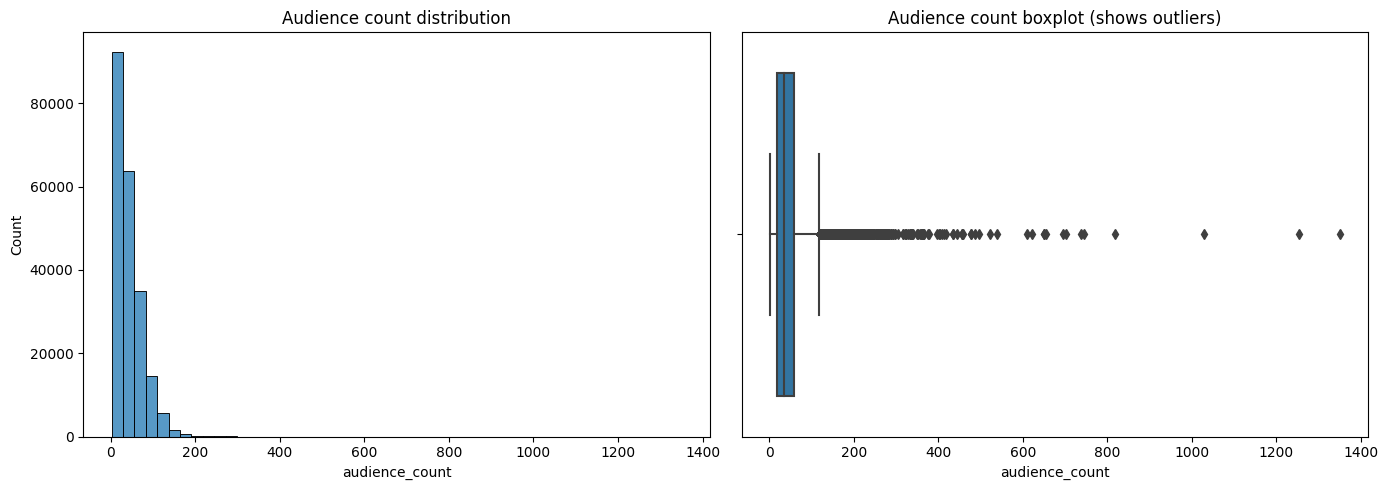

In [77]:
# histogram + boxplot
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.histplot(visits_eda['audience_count'].dropna(), bins=50, kde=False, ax=ax[0])
# histogram of audience_count
ax[0].set_title('Audience count distribution')
ax[0].set_xlabel('audience_count')
sns.boxplot(x=visits_eda['audience_count'], ax=ax[1])
# boxplot to show outliers
ax[1].set_title('Audience count boxplot (shows outliers)')
plt.tight_layout()
plt.show()

Date range in visits: 2023-01-01 00:00:00 to 2024-02-28 00:00:00


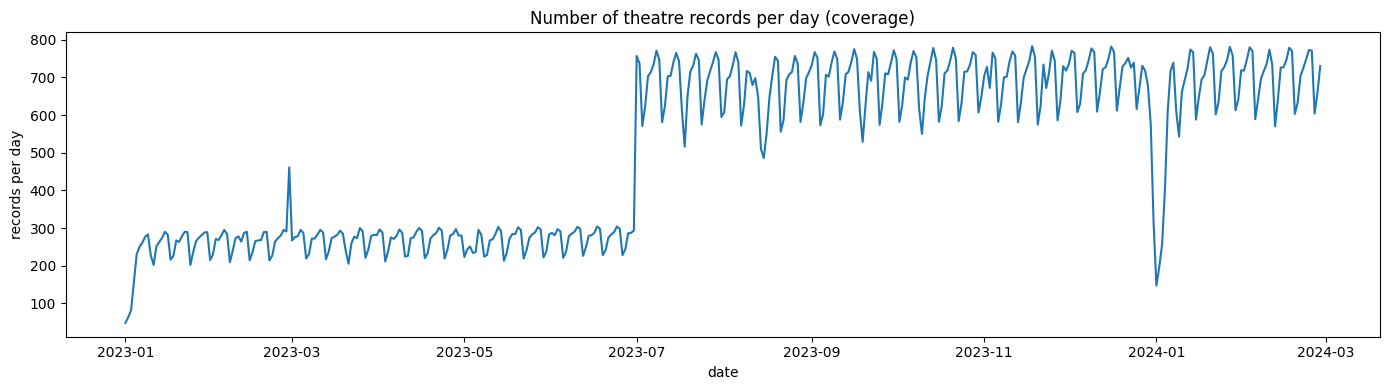

In [78]:
# Temporal coverage: show date range and number of records per date
visits_eda['show_date_dt'] = pd.to_datetime(visits_eda['show_date'])
print("Date range in visits:", visits_eda['show_date_dt'].min(), "to", visits_eda['show_date_dt'].max())
daily_counts = visits_eda.groupby('show_date_dt').size().reset_index(name='n_records')
fig, ax = plt.subplots(1,1, figsize=(14,4))
ax.plot(daily_counts['show_date_dt'], daily_counts['n_records'])
ax.set_title('Number of theatre records per day (coverage)')
ax.set_ylabel('records per day')
ax.set_xlabel('date')
plt.tight_layout()
plt.show()

,day_of_week,mean,median,count
0,Monday,47.623494,38.0,26305
1,Tuesday,35.039099,28.0,27264
2,Wednesday,35.220707,28.0,30656
3,Thursday,37.992760,32.0,30940
4,Friday,37.626460,30.0,31927
5,Saturday,45.244812,38.0,33875
6,Sunday,51.713413,44.0,33079


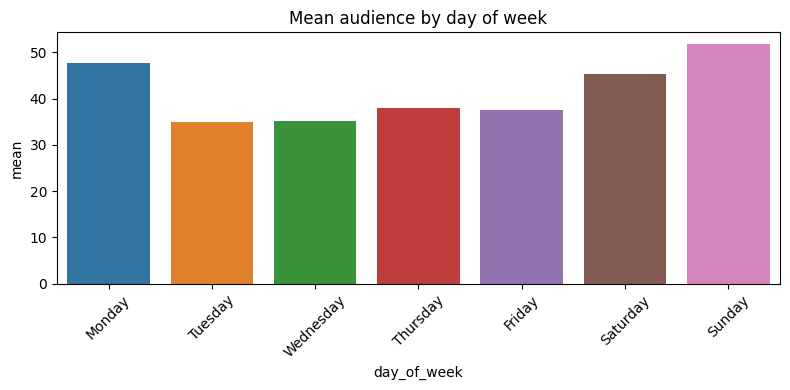

In [79]:
# Seasonality: weekday effect on audience
visits_week = visits_eda.merge(date_info, how='left', on='show_date')
weekday_stats = visits_week.groupby('day_of_week')['audience_count'].agg(['mean','median','count']).reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).reset_index()
display(weekday_stats)
fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=weekday_stats, x='day_of_week', y='mean', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title('Mean audience by day of week')
plt.tight_layout()
plt.show()

In [80]:
# Interactive scatter: BookNow tickets vs audience_count for one sample date
bn_tmp = booknow_booking.copy()
bn_tmp['show_datetime'] = pd.to_datetime(bn_tmp['show_datetime'])
bn_tmp['show_date'] = bn_tmp['show_datetime'].dt.date.astype(str)
bn_agg = bn_tmp.groupby(['book_theater_id','show_date'])['tickets_booked'].sum().reset_index()
scatter_df = visits_eda.merge(bn_agg, how='left', on=['book_theater_id','show_date'])
scatter_df = scatter_df.dropna(subset=['tickets_booked'])
sample_date = scatter_df['show_date'].iloc[-30]
sample_data = scatter_df[scatter_df['show_date'] == sample_date]
if not sample_data.empty:
    fig = px.scatter(sample_data, x='tickets_booked', y='audience_count',
                     hover_data=['book_theater_id'],
                     title=f"BookNow Tickets vs Audience Count on {sample_date}")
    fig.show()

# Basic preprocessing and helper functions

In [81]:
# convert show_datetime columns to proper datetime format and extract the date part
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
booknow_booking['show_date'] = booknow_booking['show_datetime'].dt.date.astype(str)
cinePOS_booking['show_datetime'] = pd.to_datetime(cinePOS_booking['show_datetime'])
cinePOS_booking['show_date'] = cinePOS_booking['show_datetime'].dt.date.astype(str)

In [82]:
# group booknow records by theatre and show date to compute ticket stats
booknow_agg = booknow_booking.groupby(['book_theater_id','show_date']).agg(
    bn_tickets_sum=('tickets_booked','sum'),
    bn_tickets_count=('tickets_booked','count'),
    bn_tickets_mean=('tickets_booked','mean')
).reset_index()

In [83]:
# group cinePOS data by theatre and show date to calculate ticket metrics and align with book ids
cinePOS_agg = cinePOS_booking.groupby(['cine_theater_id','show_date']).agg(
    cp_tickets_sum=('tickets_sold','sum'),
    cp_tickets_count=('tickets_sold','count'),
    cp_tickets_mean=('tickets_sold','mean')
).reset_index()

In [84]:
# join cinePOS aggregates with theatre id relation to fetch book_theater_id
cinePOS_agg = cinePOS_agg.merge(movie_theater_id_relation, how='left', on='cine_theater_id')

In [85]:
# remove cinePOS records missing book_theater_id after mapping
cinePOS_agg = cinePOS_agg.dropna(subset=['book_theater_id'])

In [86]:
cinePOS_agg = cinePOS_agg.groupby(['book_theater_id','show_date']).agg(
    cp_tickets_sum=('cp_tickets_sum','sum'),
    cp_tickets_count=('cp_tickets_count','sum'),
    cp_tickets_mean=('cp_tickets_mean','mean')
).reset_index()

In [87]:
# create a consolidated dataframe linking visits with booking, date, and theatre information
df = visits.copy()
df = df.merge(date_info, how='left', left_on='show_date', right_on='show_date')
df = df.merge(booknow_agg, how='left', left_on=['book_theater_id','show_date'], right_on=['book_theater_id','show_date'])
df = df.merge(cinePOS_agg, how='left', left_on=['book_theater_id','show_date'], right_on=['book_theater_id','show_date'])
df = df.merge(booknow_theaters, how='left', on='book_theater_id')

In [88]:
# fill missing ticket stats with 0 for consistency
df['bn_tickets_sum'] = df['bn_tickets_sum'].fillna(0)
df['bn_tickets_count'] = df['bn_tickets_count'].fillna(0)
df['bn_tickets_mean'] = df['bn_tickets_mean'].fillna(0)
df['cp_tickets_sum'] = df['cp_tickets_sum'].fillna(0)
df['cp_tickets_count'] = df['cp_tickets_count'].fillna(0)
df['cp_tickets_mean'] = df['cp_tickets_mean'].fillna(0)

In [89]:
# order data by theatre and date before lag feature creation
df = df.sort_values(['book_theater_id','show_date']).reset_index(drop=True)

In [90]:
# parse show_date as datetime for time-based features
df['show_date_dt'] = pd.to_datetime(df['show_date'])

In [91]:
# create lag 1 and 7-day rolling mean features for target and bookings
df['aud_lag_1'] = df.groupby('book_theater_id')['audience_count'].shift(1).fillna(0)
df['aud_roll_7'] = df.groupby('book_theater_id')['audience_count'].shift(1).rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True).fillna(0)
df['bn_tickets_sum_lag_1'] = df.groupby('book_theater_id')['bn_tickets_sum'].shift(1).fillna(0)
df['cp_tickets_sum_lag_1'] = df.groupby('book_theater_id')['cp_tickets_sum'].shift(1).fillna(0)

In [92]:
# encode day of week and mark weekends
dow_map = {'Monday':1,'Tuesday':2,'Wednesday':3,'Thursday':4,'Friday':5,'Saturday':6,'Sunday':7}
df['day_of_week_num'] = df['day_of_week'].map(dow_map).fillna(0)
df['is_weekend'] = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)

In [93]:
# apply ordinal encoding to categorical columns for theatre details
cat_cols = ['theater_type','theater_area']
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[cat_cols] = enc.fit_transform(df[cat_cols].fillna('missing'))

In [94]:
# set up feature names for training and evaluation
feature_cols = [
    'day_of_week_num','is_weekend',
    'bn_tickets_sum','bn_tickets_count','bn_tickets_mean',
    'cp_tickets_sum','cp_tickets_count','cp_tickets_mean',
    'aud_lag_1','aud_roll_7','bn_tickets_sum_lag_1','cp_tickets_sum_lag_1',
    'theater_type','theater_area'
]

In [95]:
X = df[feature_cols].copy()
y = df['audience_count'].values

In [96]:
# separate train and validation data using last 10 days as holdout
last_date = pd.to_datetime(df['show_date']).max()
val_start_date = (last_date - pd.Timedelta(days=10)).date().strftime('%Y-%m-%d')
train_mask = pd.to_datetime(df['show_date']) < val_start_date
X_train, X_val = X[train_mask], X[~train_mask]
y_train, y_val = y[train_mask], y[~train_mask]

In [97]:
# fill missing numeric values using SimpleImputer with median strategy
num_imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(num_imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imp = pd.DataFrame(num_imputer.transform(X_val), columns=X_val.columns, index=X_val.index)

# Model 1: RandomForest

In [98]:
%%time
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_imp, y_train)
rf_val_pred = rf.predict(X_val_imp)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
print("RandomForest RMSE:", rf_rmse )

RandomForest RMSE: 24.24418312658079
CPU times: user 3min 50s, sys: 2.65 s, total: 3min 52s
Wall time: 59.3 s


# Model 2: XGBoost

In [99]:
%%time
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=500, learning_rate=0.05, random_state=42, n_jobs= -1)
xgb_model.fit(X_train_imp, y_train, eval_set=[(X_val_imp, y_val)], early_stopping_rounds=50, verbose=False)
xgb_val_pred = xgb_model.predict(X_val_imp)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
print("XGBoost RMSE:", xgb_rmse)

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning:

`early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.



XGBoost RMSE: 21.13648529211146
CPU times: user 14.6 s, sys: 91.4 ms, total: 14.7 s
Wall time: 3.78 s


# Model 3: LightGBM

In [100]:
%%time
lgb_train = lgb.Dataset(X_train_imp, label=y_train)
lgb_val = lgb.Dataset(X_val_imp, label=y_val, reference=lgb_train)
lgb_params = {
    'objective':'regression',
    'metric':'rmse',
    'learning_rate':0.05,
    'num_leaves':31,
    'min_data_in_leaf':20,
    'verbosity':-1
}
callbacks = [lgb.early_stopping(50), lgb.log_evaluation(100)]
lgb_model = lgb.train(lgb_params, lgb_train, num_boost_round=1000, valid_sets=[lgb_val], callbacks=callbacks)
lgb_val_pred = lgb_model.predict(X_val_imp, num_iteration=lgb_model.best_iteration)
lgb_rmse = np.sqrt(mean_squared_error(y_val, lgb_val_pred))
print("LightGBM RMSE:", lgb_rmse)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 21.4285
[200]	valid_0's rmse: 21.2691
[300]	valid_0's rmse: 21.2004
[400]	valid_0's rmse: 21.1453
[500]	valid_0's rmse: 21.1233
[600]	valid_0's rmse: 21.1075
[700]	valid_0's rmse: 21.0883
Early stopping, best iteration is:
[689]	valid_0's rmse: 21.0835
LightGBM RMSE: 21.083462557367763
CPU times: user 16.4 s, sys: 180 ms, total: 16.6 s
Wall time: 4.24 s


# Compare results

In [101]:
results = pd.DataFrame({
    'model':['RandomForest','XGBoost','LightGBM'],
    'rmse':[rf_rmse, xgb_rmse, lgb_rmse]
}).sort_values('rmse')

In [102]:
print(results)

          model       rmse
2      LightGBM  21.083463
1       XGBoost  21.136485
0  RandomForest  24.244183


In [103]:
best_model_name = results.iloc[0]['model']

In [104]:
# retrain the chosen model on complete data (train + validation)
X_full = X.copy()
y_full = y.copy()
X_full_imp = pd.DataFrame(num_imputer.fit_transform(X_full), columns=X_full.columns, index=X_full.index)

In [105]:
if best_model_name == 'RandomForest':
    final_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    final_model.fit(X_full_imp, y_full)
elif best_model_name == 'XGBoost':
    final_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.03, random_state=42, n_jobs=-1)
    final_model.fit(X_full_imp, y_full, verbose=False)
else:
    final_model = lgb.LGBMRegressor(objective='regression', n_estimators=1000, learning_rate=0.03, num_leaves=31, random_state=42)
    final_model.fit(X_full_imp, y_full)

In [106]:
# generate test feature columns from composite submission ID
submission['book_theater_id'] = submission['ID'].apply(lambda x: "_".join(x.split('_')[:2]))
submission['show_date'] = submission['ID'].apply(lambda x: x.split('_')[-1])

In [107]:
test_df = submission[['book_theater_id','show_date']].merge(date_info, how='left', on='show_date')
test_df = test_df.merge(booknow_theaters, how='left', on='book_theater_id')

In [108]:
# join booking aggregate features to test data from both sources
test_df = test_df.merge(booknow_agg, how='left', left_on=['book_theater_id','show_date'], right_on=['book_theater_id','show_date'])
test_df = test_df.merge(cinePOS_agg, how='left', left_on=['book_theater_id','show_date'], right_on=['book_theater_id','show_date'])

In [109]:
# replace missing booking aggregate values with zeros
test_df['bn_tickets_sum'] = test_df['bn_tickets_sum'].fillna(0)
test_df['bn_tickets_count'] = test_df['bn_tickets_count'].fillna(0)
test_df['bn_tickets_mean'] = test_df['bn_tickets_mean'].fillna(0)
test_df['cp_tickets_sum'] = test_df['cp_tickets_sum'].fillna(0)
test_df['cp_tickets_count'] = test_df['cp_tickets_count'].fillna(0)
test_df['cp_tickets_mean'] = test_df['cp_tickets_mean'].fillna(0)

In [110]:
# extract most recent historical stats per theater for test lag features
latest_stats = df.sort_values(['book_theater_id','show_date_dt']).groupby('book_theater_id').tail(1)[['book_theater_id','audience_count','bn_tickets_sum','cp_tickets_sum','aud_roll_7']]
latest_stats = latest_stats.rename(columns={
    'audience_count':'aud_lag_1_from_hist',
    'bn_tickets_sum':'bn_tickets_sum_from_hist',
    'cp_tickets_sum':'cp_tickets_sum_from_hist',
    'aud_roll_7':'aud_roll_7_from_hist'
})

In [111]:
test_df = test_df.merge(latest_stats, how='left', on='book_theater_id')

In [112]:
for c in ['aud_lag_1_from_hist','bn_tickets_sum_from_hist','cp_tickets_sum_from_hist','aud_roll_7_from_hist']:
    test_df[c] = test_df[c].fillna(0)

In [113]:
# convert test dates and categorical columns using training encoders
test_df['day_of_week_num'] = test_df['day_of_week'].map(dow_map).fillna(0)
test_df['is_weekend'] = test_df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
test_df[cat_cols] = enc.transform(test_df[cat_cols].fillna('missing'))

In [114]:
# build final test feature set using transformed and aggregated columns
test_feature_df = pd.DataFrame({
    'day_of_week_num':test_df['day_of_week_num'],
    'is_weekend':test_df['is_weekend'],
    'bn_tickets_sum':test_df['bn_tickets_sum'],
    'bn_tickets_count':test_df['bn_tickets_count'],
    'bn_tickets_mean':test_df['bn_tickets_mean'],
    'cp_tickets_sum':test_df['cp_tickets_sum'],
    'cp_tickets_count':test_df['cp_tickets_count'],
    'cp_tickets_mean':test_df['cp_tickets_mean'],
    'aud_lag_1':test_df['aud_lag_1_from_hist'],
    'aud_roll_7':test_df['aud_roll_7_from_hist'],
    'bn_tickets_sum_lag_1':test_df['bn_tickets_sum_from_hist'],
    'cp_tickets_sum_lag_1':test_df['cp_tickets_sum_from_hist'],
    'theater_type':test_df['theater_type'],
    'theater_area':test_df['theater_area']
}, index=test_df.index)

In [115]:
# apply numeric imputer to test features
test_feature_imp = pd.DataFrame(num_imputer.transform(test_feature_df), columns=test_feature_df.columns, index=test_feature_df.index)

# Predict on test and save submission

In [116]:
test_preds = final_model.predict(test_feature_imp)

In [117]:
submission['audience_count'] = np.maximum(0, test_preds.round().astype(int))

In [118]:
submission[['ID','audience_count']].to_csv('/kaggle/working/submission.csv', index=False)